In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

print("Libraries loaded ✓")

Libraries loaded ✓


In [16]:
train = pd.read_parquet('/kaggle/input/datasets/montahalassouedd/processed-data-stores-forecasting/train.parquet')
val   = pd.read_parquet('/kaggle/input/datasets/montahalassouedd/processed-data-stores-forecasting/val.parquet')
test  = pd.read_parquet('/kaggle/input/datasets/montahalassouedd/processed-data-stores-forecasting/test.parquet')

# Make sure date is datetime
train['date'] = pd.to_datetime(train['date'])
val['date']   = pd.to_datetime(val['date'])
test['date']  = pd.to_datetime(test['date'])

print(f"Train shape : {train.shape}")
print(f"Val shape   : {val.shape}")
print(f"Test shape  : {test.shape}")
print(f"\nColumns : {train.columns.tolist()}")

Train shape : (2918916, 23)
Val shape   : (53460, 23)
Test shape  : (28512, 23)

Columns : ['date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'type_x', 'cluster', 'dcoilwtico', 'transactions', 'type_y', 'locale', 'locale_name', 'transferred', 'day_of_week', 'month', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'has_promotion', 'is_holiday']


uestion 1 : What does the sales distribution look like ?

In [17]:
# Use a family that exists
store_id = 1
family   = 'BEVERAGES'

series = train[
    (train['store_nbr'] == store_id) & 
    (train['family'] == family)
].sort_values('date').copy()

print(f"Number of days : {len(series)}")
print(f"Date range     : {series['date'].min()} → {series['date'].max()}")
print(f"\nSales stats :")
print(series['sales'].describe())
print(f"\nZero sales days : {(series['sales'] == 0).sum()}")

Number of days : 1638
Date range     : 2013-01-01 00:00:00 → 2017-06-30 00:00:00

Sales stats :
count    1638.000000
mean     1573.228327
std       726.307447
min         0.000000
25%       965.500000
50%      1520.000000
75%      2193.750000
max      5051.000000
Name: sales, dtype: float64

Zero sales days : 6


** Check distribution


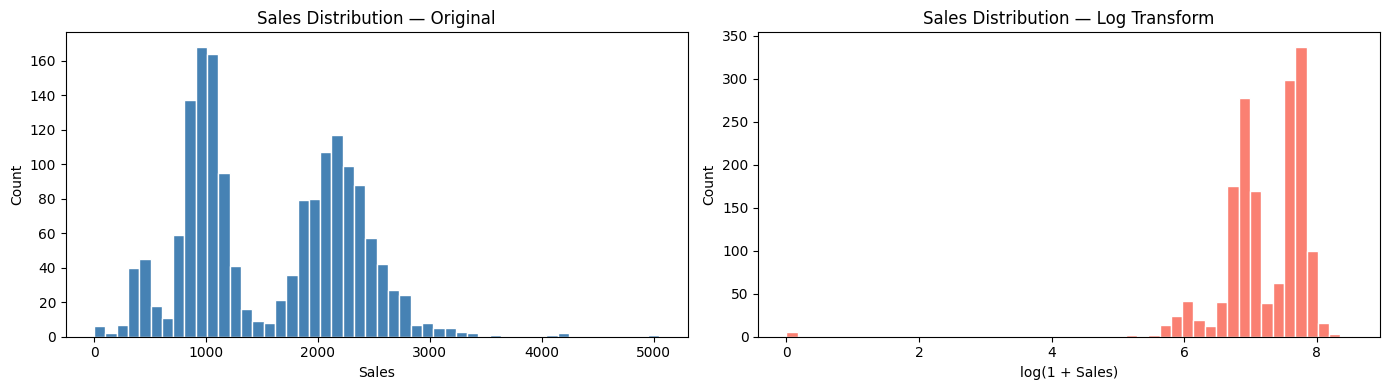

p-value original  : 0.000000
p-value log       : 0.000000
→ Still not normal — we use percentile threshold instead of 3


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Original distribution
axes[0].hist(series['sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Sales Distribution — Original')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Count')

# Log transformed
axes[1].hist(np.log1p(series['sales']), bins=50, color='salmon', edgecolor='white')
axes[1].set_title('Sales Distribution — Log Transform')
axes[1].set_xlabel('log(1 + Sales)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Normality test
stat, p_value = stats.normaltest(series['sales'].dropna())
print(f"p-value original  : {p_value:.6f}")

stat, p_value = stats.normaltest(np.log1p(series['sales']).dropna())
print(f"p-value log       : {p_value:.6f}")

if p_value > 0.05:
    print("→ Log transform looks normal ✓ Z-score is valid")
else:
    print("→ Still not normal — we use percentile threshold instead of 3")

Z-score Detection

In [19]:
WINDOW = 30

# Step 1 — Log transform
series['sales_log'] = np.log1p(series['sales'])

# Step 2 — Rolling stats
series['rolling_mean'] = series['sales_log'].rolling(
    window=WINDOW, min_periods=2).mean()
series['rolling_std'] = series['sales_log'].rolling(
    window=WINDOW, min_periods=2).std()

# Step 3 — Z-score
series['z_score'] = (
    (series['sales_log'] - series['rolling_mean']) /
    (series['rolling_std'] + 1e-8)
)

# Step 4 — Threshold (ignore NaN)
THRESHOLD = np.percentile(series['z_score'].abs().dropna(), 95)
print(f"Threshold calculated : {THRESHOLD:.4f}")

# Step 5 — Flag anomalies
series['is_anomaly_zscore'] = series['z_score'].abs() > THRESHOLD

# Summary
n_anomalies = series['is_anomaly_zscore'].sum()
print(f"Anomalies detected : {n_anomalies} / {len(series)}")
print(f"Percentage         : {n_anomalies/len(series)*100:.2f}%")
print(f"\nAnomalous days :")
print(series[series['is_anomaly_zscore']][['date', 'sales', 'z_score']])

Threshold calculated : 2.1677
Anomalies detected : 82 / 1638
Percentage         : 5.01%

Anomalous days :
              date   sales   z_score
71283   2013-02-10   185.0 -3.713827
73065   2013-02-11   172.0 -3.075701
146127  2013-03-24   390.0 -2.327135
155037  2013-03-29   280.0 -2.921223
245919  2013-05-19   354.0 -2.345547
...            ...     ...       ...
2696169 2017-02-26   690.0 -3.061826
2697951 2017-02-27   669.0 -2.647908
2779923 2017-04-14   817.0 -2.838366
2810217 2017-05-01   825.0 -2.228786
2908227 2017-06-25  1070.0 -2.198355

[82 rows x 3 columns]


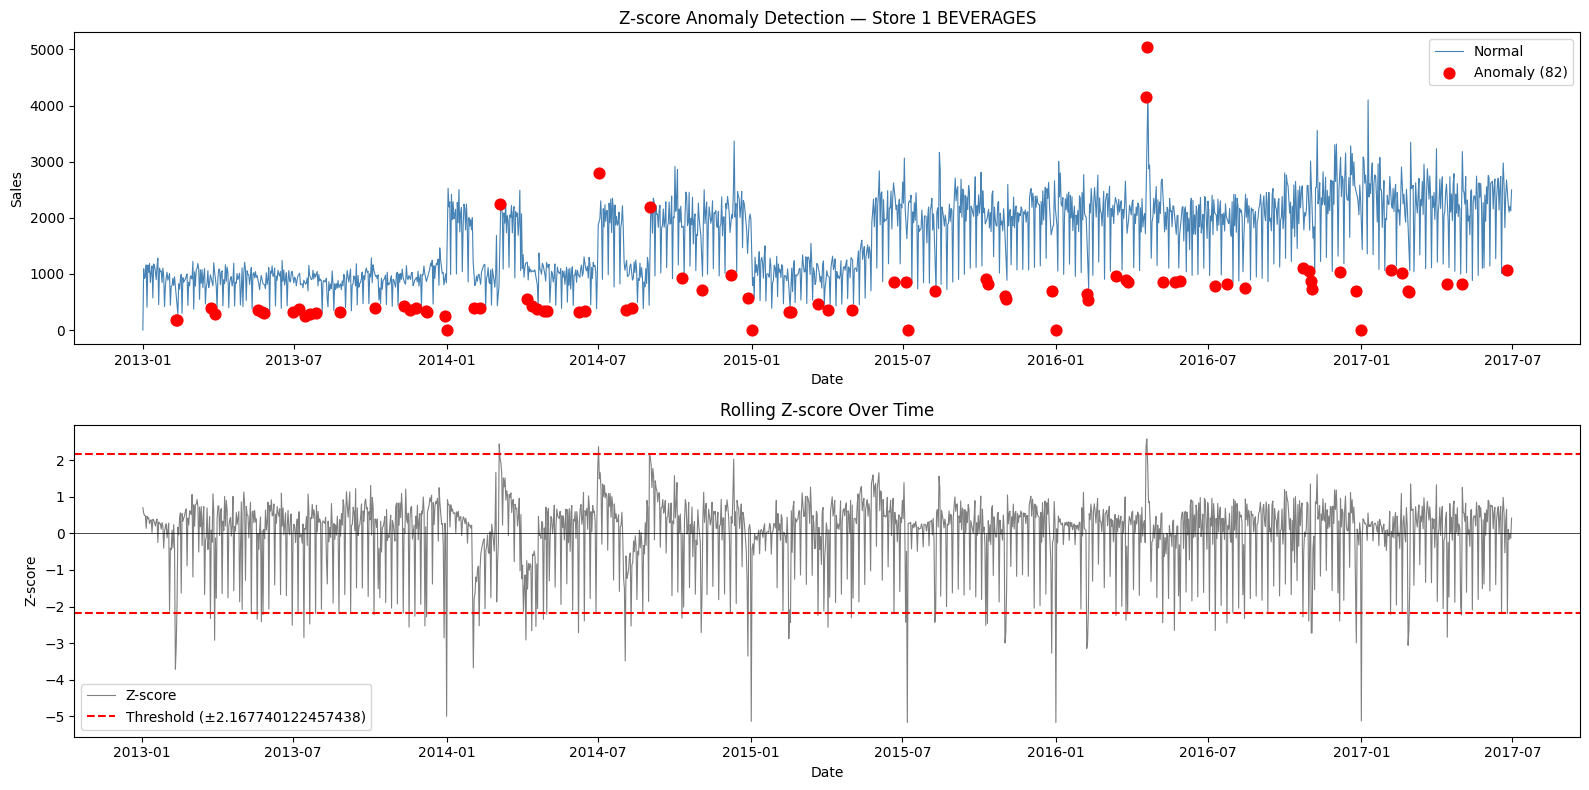

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

normal  = series[~series['is_anomaly_zscore']]
anomaly = series[series['is_anomaly_zscore']]

# Plot 1 — Sales with anomalies
axes[0].plot(normal['date'], normal['sales'],
             color='steelblue', linewidth=0.8, label='Normal')
axes[0].scatter(anomaly['date'], anomaly['sales'],
                color='red', s=60, zorder=5, label=f'Anomaly ({n_anomalies})')
axes[0].set_title(f'Z-score Anomaly Detection — Store {store_id} {family}')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sales')
axes[0].legend()

# Plot 2 — Z-score over time
axes[1].plot(series['date'], series['z_score'],
             color='gray', linewidth=0.8, label='Z-score')
axes[1].axhline(y=THRESHOLD,  color='red', linestyle='--',
                linewidth=1.5, label=f'Threshold (±{THRESHOLD})')
axes[1].axhline(y=-THRESHOLD, color='red', linestyle='--', linewidth=1.5)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_title('Rolling Z-score Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Z-score')
axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
def zscore_anomaly_detection(df, window=30, threshold=3.0):

    results = []

    for (store, fam), group in df.groupby(['store_nbr', 'family']):
        group = group.sort_values('date').copy()

        # Log transform
        group['sales_log'] = np.log1p(group['sales'])

        # Rolling stats
        group['rolling_mean'] = group['sales_log'].rolling(
            window=window, min_periods=1).mean()
        group['rolling_std']  = group['sales_log'].rolling(
            window=window, min_periods=1).std()

        # Z-score
        group['z_score'] = (
            (group['sales_log'] - group['rolling_mean']) /
            (group['rolling_std'] + 1e-8)
        )

        # Flag
        group['is_anomaly_zscore'] = group['z_score'].abs() > threshold

        results.append(group)

    return pd.concat(results).reset_index(drop=True)


# Run on full train
print("Running Z-score on all store/family combinations...")
train_zscore = zscore_anomaly_detection(train)

# Summary
total     = len(train_zscore)
anomalies = train_zscore['is_anomaly_zscore'].sum()
print(f"Total anomalies : {anomalies} / {total}")
print(f"Percentage      : {anomalies/total*100:.2f}%")

Running Z-score on all store/family combinations...
Total anomalies : 19159 / 2918916
Percentage      : 0.66%


In [22]:
# Save
train_zscore.to_parquet('train_with_zscore.parquet')
print("Z-score saved ✓")

Z-score saved ✓


Isolation Forest